# A Hartree–Fock model of Venice

American tourists in crowded European cities are faced with a three-fold set of constraints:

1. Tourists want to see the sights of the city: the Eiffel Tower, the Duomo, and so on and so forth.
2. Unfortunately, tourists also hate other tourists ("no one goes there any more, it's too crowded").
3. Finally, (American) tourists also want to walk as little as possible.

Finding a plan that satisfies these constraints might seem obvious, but it's actually surprisingly non-trivial. In fact, this problem is exactly isomorphic to the electronic structure problem under the Born–Oppenheimer approximation. Electrons are attracted to stationary nuclei, electrons repel other electrons, and increased kinetic energy comes at a cost. 

In this notebook, we'll use a simple restricted Hartree–Fock algorithm (RHF) to approximately solve this problem on a two-dimensional grid, taking a map of Venice as a case study.

## 1. Our map and our cast

The background is *Venezia-map 1-1220x900.png* by Wikimedia Commons user **Luestling**, used unmodified under [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/). See the [source and full attribution](https://commons.wikimedia.org/wiki/File:Venezia-map_1-1220x900.png).

We've chosen five "nuclei" (landmarks) by hand. Their positions are approximate pixel readings from this particular image and are not meant as exact coordinates; if you're in Venice currently and looking for directions, you should find a real map.

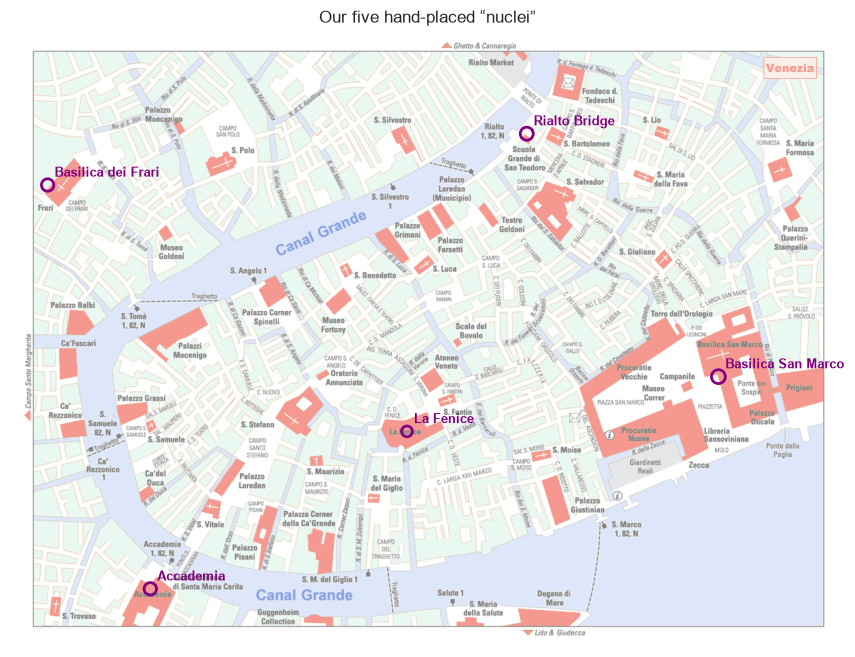

In [30]:
from pathlib import Path
import warnings

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import eigh
from scipy.sparse import diags, eye, kron

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=4, suppress=True)

MAP_PATH = Path('assets/venice_map.png')
if not MAP_PATH.exists():
    raise FileNotFoundError('Run this notebook from the project root so assets/ is visible.')
venice = mpimg.imread(MAP_PATH)[..., :3]

# Model coordinates: one unit represents 100 pixels, not a physical distance.
LX, LY = 12.2, 9.0
landmarks = {
    'Basilica San Marco': (10.35, 5.05, 2.5),
    'Rialto Bridge':      (7.55, 1.50, 2.2),
    'Basilica dei Frari': (0.55, 2.25, 2.0),
    'Accademia':          (2.05, 8.15, 2.0),
    'La Fenice':          (5.80, 5.85, 1.5),
}

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(venice, extent=(0, LX, LY, 0), alpha=0.5)
for name, (x0, y0, strength) in landmarks.items():
    ax.scatter(x0, y0, s=40 * strength, facecolors='none', edgecolors='purple', linewidths=2)
    ax.annotate(name, (x0, y0), xytext=(5, 6), textcoords='offset points',
                fontsize=9, weight='bold', color='purple')
ax.set(xlim=(0, LX), ylim=(LY, 0), title='Our five hand-placed “nuclei”')
ax.axis('off');

## 2. Translation dictionary

| Electronic structure | Venice story | Mathematical role |
|---|---|---|
| Electron | Tourist | Occupies a spatial orbital |
| Nucleus of charge $Z_A$ | Landmark of fame $Z_A$ | Attractive potential well |
| Electron–electron Coulomb repulsion | Crowd avoidance | Long-range, softened repulsion |
| Kinetic energy $-\tfrac12\nabla^2$ | Dislike of walking / sharp relocation | Penalizes rapidly varying orbitals |
| Spin-up / spin-down pair | ??? | Two tourists per spatial orbital |
| Exchange | ??? | Cancels same-particle interaction; has no classical tourist analogue |
| Self-consistent field (SCF) | Repeated walking-plan revision | Iterate until the density stops changing |


## 3. The toy Hamiltonian

For one tourist, the core Hamiltonian is

$$h = -\frac{\kappa}{2}\nabla^2 + V_{\mathrm{sites}}(\mathbf r) + V_{\mathrm{water}}(\mathbf r).$$

Landmark $A$ contributes a softened attraction

$$V_A(\mathbf r)=-\frac{Z_A}{\sqrt{|\mathbf r-\mathbf R_A|^2+a_{\rm site}^2}},$$

and two tourists interact through $w(\mathbf r,\mathbf r')=g/\sqrt{|\mathbf r-\mathbf r'|^2+a_{\rm crowd}^2}$. Softening avoids infinities on our coarse 2D grid. We infer water pixels from the map's pale blue color and assign them a finite penalty (not infinite because of vaporetti and bridges).

### Details and simplifications worth noticing
- This is a 30×22 rectangular grid, not a smarter street model. One model unit is 100 map pixels.
- Dirichlet boundaries make orbitals vanish just outside the picture.

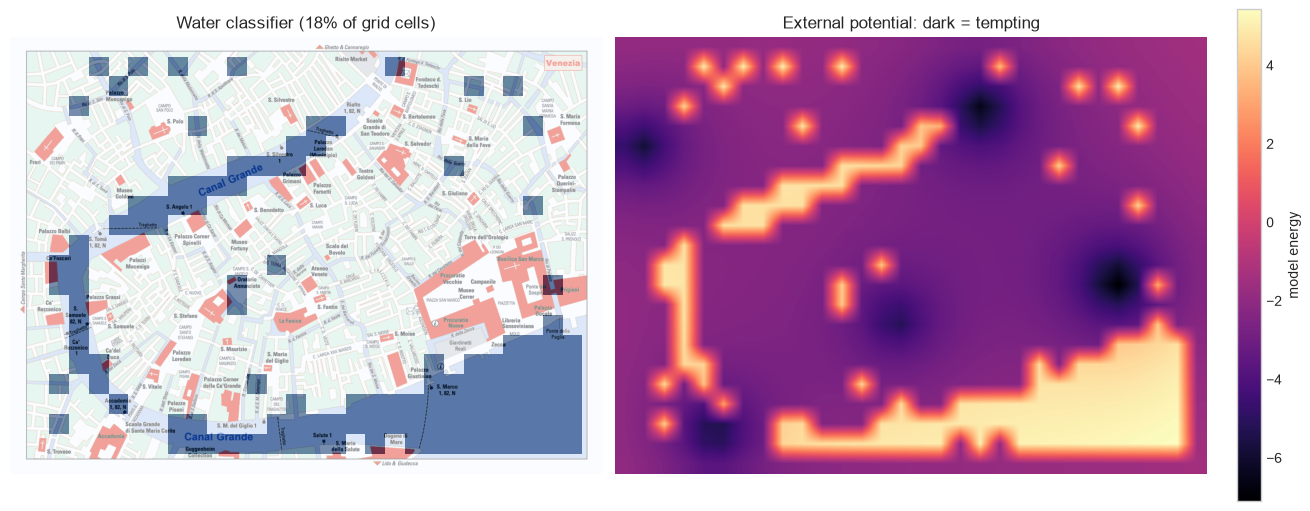

In [31]:
# The knobs: change these later and rerun from here.
NX, NY = 30, 22
N_TOURISTS = 4                 # RHF requires an even number
KINETIC_SCALE = 3.0            # larger -> smoother, more spread-out itineraries
CROWD_STRENGTH = 3          # larger -> stronger tourist avoidance
WATER_PENALTY = 7.0            # larger -> stronger reluctance to occupy canals
SITE_SOFTENING = 0.42
CROWD_SOFTENING = 0.38

if N_TOURISTS % 2:
    raise ValueError('This restricted, closed-shell model needs an even tourist count.')

dx, dy = LX / NX, LY / NY
xs = (np.arange(NX) + 0.5) * dx
ys = (np.arange(NY) + 0.5) * dy
X, Y = np.meshgrid(xs, ys)
points = np.column_stack((X.ravel(), Y.ravel()))
n_grid = points.shape[0]

# Sample the background image at grid-cell centers. Blue-dominant pixels are water.
pixel_x = np.clip((xs / LX * venice.shape[1]).astype(int), 0, venice.shape[1] - 1)
pixel_y = np.clip((ys / LY * venice.shape[0]).astype(int), 0, venice.shape[0] - 1)
sampled_rgb = venice[np.ix_(pixel_y, pixel_x)]
water = ((sampled_rgb[..., 2] - sampled_rgb[..., 1] > 0.07) &
         (sampled_rgb[..., 2] - sampled_rgb[..., 0] > 0.12))

# Five-point finite-difference representation of -1/2 Laplacian.
def second_derivative(n, spacing):
    return diags([np.ones(n-1), -2*np.ones(n), np.ones(n-1)], [-1, 0, 1]) / spacing**2

laplacian = kron(eye(NY), second_derivative(NX, dx)) + kron(second_derivative(NY, dy), eye(NX))
kinetic = (-0.5 * KINETIC_SCALE * laplacian).toarray()

v_sites = np.zeros_like(X)
for x0, y0, strength in landmarks.values():
    v_sites -= strength / np.sqrt((X-x0)**2 + (Y-y0)**2 + SITE_SOFTENING**2)
v_external = v_sites + WATER_PENALTY * water
h_core = kinetic + np.diag(v_external.ravel())

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
axes[0].imshow(venice, extent=(0, LX, LY, 0))
axes[0].imshow(water, extent=(0, LX, LY, 0), cmap='Blues', alpha=0.55, interpolation='nearest')
axes[0].set_title(f'Water classifier ({water.mean():.0%} of grid cells)')
im = axes[1].imshow(v_external, extent=(0, LX, LY, 0), cmap='magma', interpolation='bilinear')
axes[1].set_title('External potential: dark = tempting')
fig.colorbar(im, ax=axes[1], label='model energy')
for ax in axes:
    ax.set(xlim=(0, LX), ylim=(LY, 0)); ax.axis('off')

## 4. Hartree–Fock in one paragraph (and one matrix)

We seek spatial orbitals $\phi_i$, each holding two tourists. From the occupied orbitals we build the density matrix $P=2CC^T$. The Fock matrix is

$$F[P] = h + J[P] - \tfrac12 K[P],$$

where $J$ is the crowd-repulsion (Coulomb) potential and $K$ is exchange. On this real-space grid, $J_{ii}=\sum_k w_{ik}P_{kk}$ and $K_{ij}=w_{ij}P_{ij}$. We diagonalize $F$, occupy the lowest orbitals up to the number of tourists, rebuild $P$, and repeat. Density mixing prevents excessive reorganization.

The calculation is variational within the grid and RHF ansatz, but this simple fixed-point algorithm is not guaranteed to find the global minimum. (That is true of Hartree–Fock approaches in chemistry too.)

In [35]:
# Pairwise softened interaction matrix. For 660 grid points this is small enough to show directly.
delta = points[:, None, :] - points[None, :, :]
distance2 = np.einsum('ijk,ijk->ij', delta, delta)
interaction = CROWD_STRENGTH / np.sqrt(distance2 + CROWD_SOFTENING**2)

def rhf_energy(P, h, W):
    J = W @ np.diag(P)
    K = W * P
    return (np.sum(P * h.T)
            + 0.5 * np.dot(np.diag(P), J)
            - 0.25 * np.sum(P * K))

def solve_rhf(h, W, n_tourists=6, mixing=0.30, tolerance=2e-7, max_iter=100, verbose=True):
    n_occ = n_tourists // 2
    orbital_energies, C = eigh(h, subset_by_index=(0, n_occ - 1))
    P = 2.0 * C @ C.T
    history = []

    for iteration in range(1, max_iter + 1):
        J = W @ np.diag(P)
        K = W * P
        F = h + np.diag(J) - 0.5 * K
        orbital_energies, C_new = eigh(F, subset_by_index=(0, n_occ - 1))
        P_target = 2.0 * C_new @ C_new.T
        rms_change = np.linalg.norm(P_target - P) / np.sqrt(P.size)
        P = (1.0 - mixing) * P + mixing * P_target
        energy = rhf_energy(P, h, W)
        history.append((iteration, energy, rms_change))
        if verbose and (iteration <= 5 or iteration % 5 == 0 or rms_change < tolerance):
            print(f'iteration {iteration:2d}  E = {energy: .8f}  density RMS = {rms_change:.3e}')
        if rms_change < tolerance:
            break
    else:
        warnings.warn('SCF reached max_iter before the requested tolerance.')

    # Return orbitals consistent with the final Fock matrix. P remains the smoothly converged density.
    J = W @ np.diag(P)
    K = W * P
    F = h + np.diag(J) - 0.5 * K
    orbital_energies, C = eigh(F, subset_by_index=(0, n_occ - 1))
    return P, orbital_energies, C, np.asarray(history)

P_hf, orbital_energies, orbitals, history = solve_rhf(h_core, interaction, N_TOURISTS)

iteration  1  E = -2.42549018  density RMS = 5.572e-03
iteration  2  E = -2.65413392  density RMS = 2.813e-03
iteration  3  E = -2.85372783  density RMS = 2.015e-03
iteration  4  E = -3.02262474  density RMS = 1.520e-03
iteration  5  E = -3.15811046  density RMS = 1.128e-03
iteration 10  E = -3.47941298  density RMS = 3.521e-04
iteration 15  E = -3.55107237  density RMS = 1.790e-04
iteration 20  E = -3.56718250  density RMS = 1.064e-04
iteration 25  E = -3.57126449  density RMS = 6.691e-05
iteration 30  E = -3.57248933  density RMS = 4.345e-05
iteration 35  E = -3.57292296  density RMS = 2.879e-05
iteration 40  E = -3.57309622  density RMS = 1.930e-05
iteration 45  E = -3.57317063  density RMS = 1.304e-05
iteration 50  E = -3.57320384  density RMS = 8.841e-06
iteration 55  E = -3.57321897  density RMS = 6.013e-06
iteration 60  E = -3.57322593  density RMS = 4.096e-06
iteration 65  E = -3.57322915  density RMS = 2.794e-06
iteration 70  E = -3.57323065  density RMS = 1.907e-06
iteration 

Integrated tourist density = 4.00000000 (target: 4)
Occupied orbital energies: [0.131  0.6849]
Final RHF energy = -3.57323194


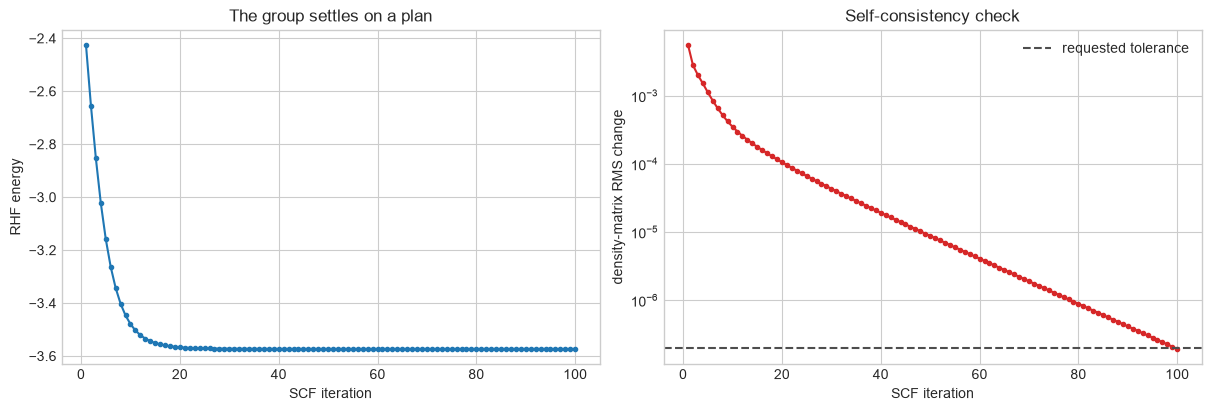

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(history[:, 0], history[:, 1], 'o-', ms=3)
axes[0].set(xlabel='SCF iteration', ylabel='RHF energy', title='The group settles on a plan')
axes[1].semilogy(history[:, 0], history[:, 2], 'o-', ms=3, color='tab:red')
axes[1].axhline(2e-7, ls='--', color='0.3', label='requested tolerance')
axes[1].set(xlabel='SCF iteration', ylabel='density-matrix RMS change', title='Self-consistency check')
axes[1].legend();

print(f'Integrated tourist density = {np.trace(P_hf):.8f} (target: {N_TOURISTS})')
print('Occupied orbital energies:', orbital_energies)
print(f'Final RHF energy = {rhf_energy(P_hf, h_core, interaction):.8f}')

A converged calculation has a falling (or nearly settled) energy, a density change below the dashed line, and integrated density exactly equal to six. 

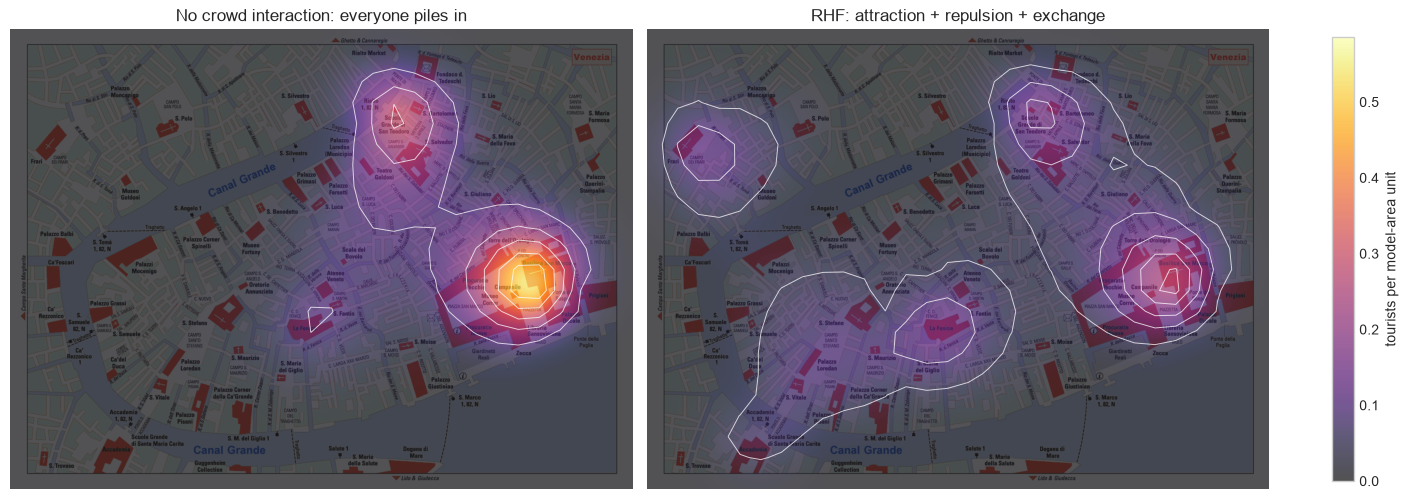

In [37]:
# Compare tourists who ignore one another with self-consistent RHF tourists.
_, C_independent = eigh(h_core, subset_by_index=(0, N_TOURISTS // 2 - 1))
P_independent = 2 * C_independent @ C_independent.T
density_independent = np.diag(P_independent).reshape(NY, NX) / (dx * dy)
density_hf = np.diag(P_hf).reshape(NY, NX) / (dx * dy)
vmax = max(density_independent.max(), density_hf.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
titles = ['No crowd interaction: everyone piles in', 'RHF: attraction + repulsion + exchange']
for ax, density, title in zip(axes, [density_independent, density_hf], titles):
    ax.imshow(venice, extent=(0, LX, LY, 0), alpha=0.72)
    layer = ax.imshow(density, extent=(0, LX, LY, 0), cmap='inferno', alpha=0.68,
                      interpolation='bicubic', vmin=0, vmax=vmax)
    ax.contour(X, Y, density, levels=5, colors='white', linewidths=0.7, alpha=0.75)
    ax.set(xlim=(0, LX), ylim=(LY, 0), title=title); ax.axis('off')
fig.colorbar(layer, ax=axes, shrink=0.75, label='tourists per model-area unit');

## 5. Orbitals

The density is observable-like: it says where tourists are likely to be found. Individual occupied orbitals are mathematical ingredients and can be rotated among themselves without changing the RHF state. Still, plotting the canonical orbitals is instructive, although the physical interpretation of these orbitals within the tourist model is unclear.

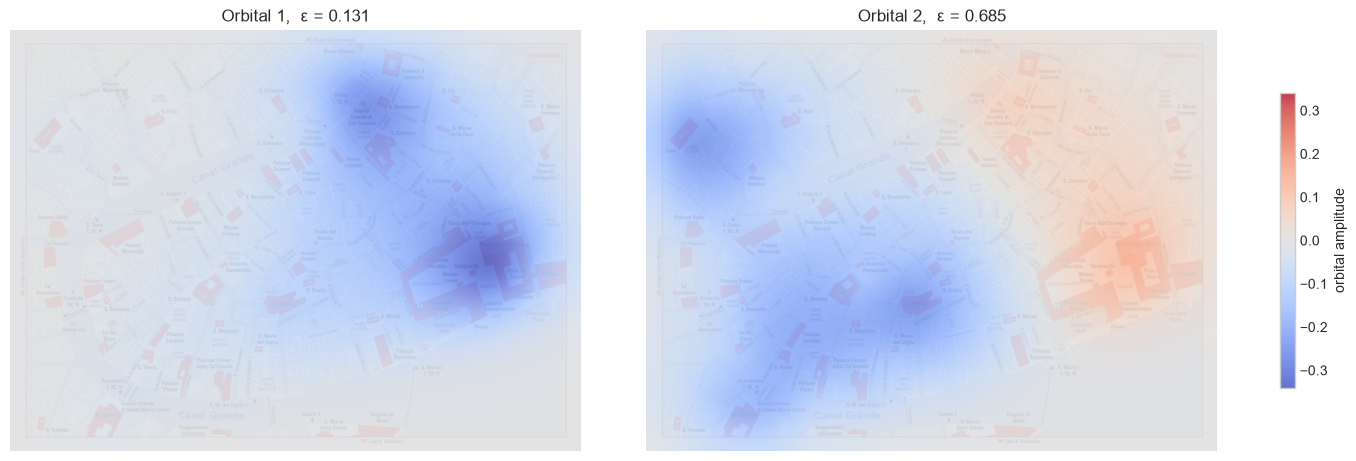

In [38]:
fig, axes = plt.subplots(1, N_TOURISTS // 2, figsize=(14, 4.5), constrained_layout=True)
amplitude = np.max(np.abs(orbitals)) / np.sqrt(dx * dy)
for i, ax in enumerate(axes.flat):
    psi = orbitals[:, i].reshape(NY, NX) / np.sqrt(dx * dy)
    ax.imshow(venice, extent=(0, LX, LY, 0), alpha=0.34)
    image = ax.imshow(psi, extent=(0, LX, LY, 0), cmap='coolwarm', alpha=0.78,
                      vmin=-amplitude, vmax=amplitude, interpolation='bicubic')
    ax.set_title(f'Orbital {i+1},  ε = {orbital_energies[i]:.3f}')
    ax.set(xlim=(0, LX), ylim=(LY, 0)); ax.axis('off')
fig.colorbar(image, ax=axes, shrink=0.7, label='orbital amplitude');